# Student Admission Fairness Analysis

Testing AIDE-ML's ability to create fair admission prediction models across different demographic groups.

## Dataset Description: Student Admission (Synthetic)

A synthetic dataset of **12,000 student applications** with built-in systemic biases. The task is to predict whether a student will be **admitted** or **rejected**.

### Features:

**Protected Attributes (Sensitive):**
- **gender**: Male, Female, Non-binary
- **race**: White, Black, Hispanic, Asian, Native American, Other
- **socioeconomic_status**: Low, Middle, High
- **first_generation**: Yes/No (first-generation college student)
- **region**: Northeast, Southeast, Midwest, Southwest, West
- **urban_rural**: Urban, Suburban, Rural
- **disability_status**: Yes/No

**Academic Metrics:**
- **gpa**: High school GPA (0.0 - 4.0)
- **sat_score**: SAT score (400 - 1600)
- **act_score**: ACT score (1 - 36)
- **ap_courses**: Number of AP courses (0 - 12)
- **honors_courses**: Number of honors courses (0 - 15)
- **class_rank_percentile**: Class rank percentile (0 - 100)

**Activities & Essays:**
- **extracurriculars**: Number of extracurricular activities (0 - 10)
- **leadership_positions**: Number of leadership roles (0 - 5)
- **community_service_hours**: Volunteer hours (0 - 500)
- **awards_honors**: Academic awards (0 - 8)
- **essay_score**: Essay quality (1 - 10)
- **recommendation_strength**: Letter of recommendation strength (1 - 10)

**Target Variable:**
- **admitted**: 1 (Admitted) or 0 (Rejected)

### Built-in Biases:

The dataset intentionally includes realistic systemic biases:
1. **Socioeconomic**: Higher SES students have better test scores (access to test prep), more AP courses (school resources), stronger recommendations (network access)
2. **Racial**: Correlation between race and SES, test score gaps, admission bias favoring White and Asian applicants
3. **Geographic**: Rural students have fewer resources and opportunities
4. **First-generation**: Disadvantaged despite diversity claims
5. **Gender**: Subtle bias in admission decisions favoring male applicants

### Fairness Goal:

Build models that:
- Maintain high accuracy (≥ 80%)
- Minimize disparities across protected groups
- Achieve fair metrics:
  - **Demographic Parity Difference** ≤ 0.15
  - **Equal Opportunity Difference** ≤ 0.10

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Dataset paths
DATA_DIR = "../../resources/datasets/student-admission"

# Load train and test sets
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nTarget distribution (train):")
print(train_df['admitted'].value_counts(normalize=True))
print(f"\nAdmission rate: {train_df['admitted'].mean():.1%}")

Train shape: (9600, 20)
Test shape: (2400, 20)

Columns: ['gender', 'race', 'socioeconomic_status', 'first_generation', 'region', 'urban_rural', 'disability_status', 'gpa', 'sat_score', 'act_score', 'ap_courses', 'honors_courses', 'class_rank_percentile', 'extracurriculars', 'leadership_positions', 'community_service_hours', 'awards_honors', 'essay_score', 'recommendation_strength', 'admitted']

Target distribution (train):
admitted
0    0.7
1    0.3
Name: proportion, dtype: float64

Admission rate: 30.0%


## 1. Baseline Model with AIDE

### 1.1 AIDE Baseline Model Training

Train a baseline model using AIDE-ML with a simple accuracy-focused prompt (no fairness considerations).

**AIDE Prompt:**

```bash
aide data_dir="resources/datasets/student-admission" \
     goal="Predict student admission decisions" \
     eval="accuracy"
```

In [2]:
# AIDE Baseline Model - Best Solution
# Generated by AIDE-ML with goal: "Predict student admission decisions"

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint
from lightgbm import LGBMClassifier

# Separate features and target
X_train = train_df.drop("admitted", axis=1)
y_train = train_df["admitted"]
X_test = test_df.drop("admitted", axis=1)
y_test = test_df["admitted"]

# One-hot encode categorical variables
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
X_train_enc = pd.get_dummies(X_train, columns=cat_cols)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols)
# Align test set columns with train set
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f"Training set: {X_train_enc.shape}")
print(f"Test set: {X_test_enc.shape}")

# Set up stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter distributions for LightGBM
param_dist = {
    "num_leaves": randint(20, 150),
    "n_estimators": randint(100, 500),
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [-1] + list(range(3, 16)),
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

# Randomized search
print("\nRunning RandomizedSearchCV (20 iterations)...")
lgb = LGBMClassifier(random_state=42, n_jobs=-1)
rs = RandomizedSearchCV(
    lgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=1
)
rs.fit(X_train_enc, y_train)

print(f"\nBest CV accuracy: {rs.best_score_:.4f}")
print("Best parameters:", rs.best_params_)

# Get best model and predict on test set
baseline_model = rs.best_estimator_
baseline_preds = baseline_model.predict(X_test_enc).astype(int)
baseline_proba = baseline_model.predict_proba(X_test_enc)[:, 1]

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, baseline_preds)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, baseline_preds, target_names=['Rejected', 'Admitted']))

Training set: (9600, 36)
Test set: (2400, 36)

Running RandomizedSearchCV (20 iterations)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2304, number of negative: 5376
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002278 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 858
[LightGBM] [Info] Number of data points in the train set: 7680, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2304, number of negative: 5376
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001703 seconds.
You can set `force_row

### 1.2 Baseline Fairness Evaluation

Evaluate the fairness of the baseline model across protected attributes.

In [3]:
from sklearn.metrics import accuracy_score, confusion_matrix

def calculate_fairness_metrics(y_true, y_pred, sensitive_features, group_name="Group"):
    """
    Calculate accuracy, demographic parity difference, and equal opportunity difference.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        sensitive_features: Array of group memberships
        group_name: Name of the protected attribute
    
    Returns:
        Dictionary with fairness metrics
    """
    df = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
        'group': sensitive_features
    })
    
    # Overall accuracy
    acc = accuracy_score(y_true, y_pred)
    
    # Selection Rate (for Demographic Parity)
    # Percentage of positive predictions in each group
    selection_rates = df.groupby('group')['y_pred'].mean()
    dp_diff = selection_rates.max() - selection_rates.min()
    
    # True Positive Rate (for Equal Opportunity)
    # TPR = TP / (TP + FN) = TP / Actual Positives
    pos_df = df[df['y_true'] == 1]
    if len(pos_df) > 0:
        tpr_rates = pos_df.groupby('group')['y_pred'].mean()
        eo_diff = tpr_rates.max() - tpr_rates.min()
    else:
        tpr_rates = pd.Series()
        eo_diff = 0.0
    
    print(f"\n{group_name.upper()} Fairness Metrics")
    print("=" * 60)
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Demographic Parity Difference: {dp_diff:.4f}")
    print(f"Equal Opportunity Difference: {eo_diff:.4f}")
    
    print(f"\nSelection Rates by {group_name}:")
    for group, rate in selection_rates.items():
        print(f"  {group}: {rate:.4f}")
    
    if len(tpr_rates) > 0:
        print(f"\nTrue Positive Rates by {group_name}:")
        for group, rate in tpr_rates.items():
            print(f"  {group}: {rate:.4f}")
    
    return {
        "Accuracy": acc,
        "DP Difference": dp_diff,
        "EO Difference": eo_diff,
        "Selection Rates": selection_rates.to_dict(),
        "TPR Rates": tpr_rates.to_dict() if len(tpr_rates) > 0 else {}
    }

# Evaluate fairness across protected attributes
print("BASELINE MODEL FAIRNESS EVALUATION")
print("="*70)

baseline_metrics_race = calculate_fairness_metrics(y_test, baseline_preds, test_df['race'], 'Race')
baseline_metrics_gender = calculate_fairness_metrics(y_test, baseline_preds, test_df['gender'], 'Gender')
baseline_metrics_ses = calculate_fairness_metrics(y_test, baseline_preds, test_df['socioeconomic_status'], 'SES')
baseline_metrics_firstgen = calculate_fairness_metrics(y_test, baseline_preds, test_df['first_generation'], 'First Generation')

BASELINE MODEL FAIRNESS EVALUATION

RACE Fairness Metrics
Overall Accuracy: 0.8883
Demographic Parity Difference: 0.4651
Equal Opportunity Difference: 0.5490

Selection Rates by Race:
  Asian: 0.5021
  Black: 0.0868
  Hispanic: 0.0658
  Native American: 0.0370
  Other: 0.2400
  White: 0.3743

True Positive Rates by Race:
  Asian: 0.8547
  Black: 0.6250
  Hispanic: 0.4510
  Native American: 0.5000
  Other: 1.0000
  White: 0.8114

GENDER Fairness Metrics
Overall Accuracy: 0.8883
Demographic Parity Difference: 0.0060
Equal Opportunity Difference: 0.0344

Selection Rates by Gender:
  Female: 0.2856
  Male: 0.2815
  Non-binary: 0.2796

True Positive Rates by Gender:
  Female: 0.7733
  Male: 0.7971
  Non-binary: 0.8077

SES Fairness Metrics
Overall Accuracy: 0.8883
Demographic Parity Difference: 0.7978
Equal Opportunity Difference: 0.8819

Selection Rates by SES:
  High: 0.8003
  Low: 0.0025
  Middle: 0.1972

True Positive Rates by SES:
  High: 0.9295
  Low: 0.0476
  Middle: 0.5628

FIRST GE

## 2. Simple Fairness-Prompted Model

### 2.1 AIDE Simple Fairness Model Training

Train a model with explicit fairness instructions in the prompt.

**AIDE Prompt:**

```bash
aide data_dir="resources/datasets/student-admission" \
     goal="Predict student admission decisions with fairness across race, gender, and socioeconomic status" \
     eval="accuracy and fairness metrics (demographic parity, equal opportunity)"
```

In [4]:
# AIDE Fairness-Prompted Model - Best Solution
# Generated by AIDE-ML with goal: "Predict student admission decisions with fairness across race, gender, and socioeconomic status"

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

# Define protected attributes
protected_attrs = ["race", "gender", "socioeconomic_status"]

# Prepare data (remove protected attributes from features)
y_train = train_df["admitted"]
X_train_fair = train_df.drop(["admitted"] + protected_attrs, axis=1)
X_prot_train = train_df[protected_attrs]

y_test = test_df["admitted"]
X_test_fair = test_df.drop(["admitted"] + protected_attrs, axis=1)
X_prot_test = test_df[protected_attrs]

# Identify numeric and categorical features
numeric_features = X_train_fair.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train_fair.select_dtypes(include=["object"]).columns.tolist()

print(f"Training without protected attributes: {protected_attrs}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

base_clf = Pipeline([
    ("pre", preprocessor),
    ("lgb", LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1)),
])

def compute_reweights(prot_df, y_series):
    """Compute sample weights to balance intersectional groups"""
    grp = prot_df.astype(str).agg("_".join, axis=1)
    df = pd.DataFrame({"grp": grp, "y": y_series})
    N = len(df)
    p_grp = df.grp.value_counts() / N
    p_y = df.y.value_counts() / N
    p_joint = df.groupby(["grp", "y"]).size() / N
    weights = df.apply(
        lambda row: (p_grp[row.grp] * p_y[row.y]) / p_joint.loc[(row.grp, row.y)],
        axis=1,
    )
    return weights.values

def compute_equalized_odds_gap(y_true, y_pred, prot_df):
    """Compute average equalized odds gap across protected attributes"""
    gaps = []
    for attr in protected_attrs:
        tprs, fprs = [], []
        for grp in prot_df[attr].unique():
            mask = prot_df[attr] == grp
            yt, yp = y_true[mask], y_pred[mask]
            pos = yt == 1
            neg = yt == 0
            if pos.sum() > 0:
                tprs.append((yp[pos] == 1).sum() / pos.sum())
            if neg.sum() > 0:
                fprs.append((yp[neg] == 1).sum() / neg.sum())
        gap = max(
            (max(tprs) - min(tprs)) if len(tprs) > 1 else 0,
            (max(fprs) - min(fprs)) if len(fprs) > 1 else 0,
        )
        gaps.append(gap)
    return np.mean(gaps)

# Compute reweights for fairness
print("\nComputing reweights for fairness...")
w_train = compute_reweights(X_prot_train, y_train)
print(f"Weight range: [{w_train.min():.3f}, {w_train.max():.3f}]")

# Train with sample weights
print("\nTraining fairness-aware model with reweighting...")
base_clf.fit(X_train_fair, y_train, lgb__sample_weight=w_train)

# Calibrate probabilities
print("Calibrating probabilities...")
calib_clf = CalibratedClassifierCV(base_clf, cv="prefit", method="isotonic")
calib_clf.fit(X_train_fair, y_train)

# Find optimal threshold on training set for fairness
print("Optimizing threshold for fairness...")
thresholds = np.linspace(0.2, 0.8, 31)
proba_train = calib_clf.predict_proba(X_train_fair)[:, 1]

best_thr, best_score = 0.5, -np.inf
for thr in thresholds:
    y_pred_train = (proba_train >= thr).astype(int)
    acc = accuracy_score(y_train, y_pred_train)
    gap = compute_equalized_odds_gap(y_train, y_pred_train, X_prot_train)
    score = acc - gap  # Composite metric
    if score > best_score:
        best_score, best_thr = score, thr

print(f"Best threshold: {best_thr:.3f}")

# Predict on test set with optimal threshold
proba_test = calib_clf.predict_proba(X_test_fair)[:, 1]
fair_preds = (proba_test >= best_thr).astype(int)

# Calculate test accuracy
fair_test_accuracy = accuracy_score(y_test, fair_preds)
print(f"\nTest Accuracy: {fair_test_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, fair_preds, target_names=['Rejected', 'Admitted']))

Training without protected attributes: ['race', 'gender', 'socioeconomic_status']
Numeric features: 12
Categorical features: 4

Computing reweights for fairness...
Weight range: [0.321, 75.900]

Training fairness-aware model with reweighting...
[LightGBM] [Info] Number of positive: 2880, number of negative: 6720
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 834
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.270572 -> initscore=-0.991722
[LightGBM] [Info] Start training from score -0.991722
Calibrating probabilities...
Optimizing threshold for fairness...
Best threshold: 0.300

Test Accuracy: 0.8450

Classification Report:
              precision    recall  f1-score   support

    Rejecte

### 2.2 Simple Fairness Model Evaluation

Evaluate fairness metrics for the simple fairness-prompted model.

In [5]:
# Evaluate fairness metrics for fairness-prompted model

print("FAIRNESS-PROMPTED MODEL FAIRNESS EVALUATION")
print("="*70)

# Evaluate fairness across protected attributes
fair_metrics_race = calculate_fairness_metrics(y_test, fair_preds, test_df['race'], 'Race')
fair_metrics_gender = calculate_fairness_metrics(y_test, fair_preds, test_df['gender'], 'Gender')
fair_metrics_ses = calculate_fairness_metrics(y_test, fair_preds, test_df['socioeconomic_status'], 'SES')
fair_metrics_firstgen = calculate_fairness_metrics(y_test, fair_preds, test_df['first_generation'], 'First Generation')

FAIRNESS-PROMPTED MODEL FAIRNESS EVALUATION

RACE Fairness Metrics
Overall Accuracy: 0.8450
Demographic Parity Difference: 0.4208
Equal Opportunity Difference: 0.5000

Selection Rates by Race:
  Asian: 0.5319
  Black: 0.1910
  Hispanic: 0.2281
  Native American: 0.1111
  Other: 0.2200
  White: 0.4077

True Positive Rates by Race:
  Asian: 0.8632
  Black: 0.8125
  Hispanic: 0.8431
  Native American: 0.5000
  Other: 1.0000
  White: 0.8114

GENDER Fairness Metrics
Overall Accuracy: 0.8450
Demographic Parity Difference: 0.0203
Equal Opportunity Difference: 0.0622

Selection Rates by Gender:
  Female: 0.3537
  Male: 0.3461
  Non-binary: 0.3333

True Positive Rates by Gender:
  Female: 0.8198
  Male: 0.8314
  Non-binary: 0.7692

SES Fairness Metrics
Overall Accuracy: 0.8450
Demographic Parity Difference: 0.7054
Equal Opportunity Difference: 0.3068

Selection Rates by SES:
  High: 0.7604
  Low: 0.0550
  Middle: 0.3373

True Positive Rates by SES:
  High: 0.8782
  Low: 0.5714
  Middle: 0.7359


## 3. Advanced Fairness-Constrained Model

### 3.1 AIDE Advanced Fairness Model Training

The previous fairness-prompted model showed only marginal improvements. Let's try a more detailed prompt that explicitly instructs AIDE to use advanced fairness techniques.

### Strategy:
Instead of a vague "with fairness" instruction, we'll provide specific guidance:

1. **Explicit Fairness Constraints**: Set numerical targets (DP ≤ 0.15, EO ≤ 0.10)
2. **Fairlearn Integration**: Request use of fairlearn library's fairness algorithms
3. **Post-processing Methods**: Mention threshold optimization per group
4. **Constraint-based Optimization**: Suggest techniques like Exponentiated Gradient or Grid Search
5. **Multi-objective Optimization**: Balance accuracy and fairness explicitly

### Why This Might Work Better:
- **Specificity**: Clear targets give AIDE a concrete objective function
- **Library Guidance**: Pointing to fairlearn enables proven techniques

- **Multiple Techniques**: Suggesting several approaches lets AIDE explore combinations- **Numerical Constraints**: Makes fairness violations measurable and optimizable

**Advanced AIDE Prompt with Fairness Constraints:**

```bash
aide data_dir="resources/datasets/student-admission" \
     goal="Predict student admission decisions with strict fairness constraints. Use fairlearn library to enforce demographic parity difference ≤ 0.15 and equal opportunity difference ≤ 0.10 across race, gender, and socioeconomic_status. Consider techniques like fairlearn ThresholdOptimizer for post-processing with separate thresholds per group, ExponentiatedGradient for constraint-based training, GridSearch with fairness constraints, or per-group calibration. Remove sensitive features during training but use them for fairness evaluation and post-processing." \
     eval="balanced metric combining accuracy and fairness violations with targets of demographic parity below 0.15 and equal opportunity below 0.10"
```

**Key Differences from Previous Prompt:**
- ✓ **Numerical targets**: Explicit thresholds (DP ≤ 0.15, EO ≤ 0.10, accuracy ≥ 80%)
- ✓ **Library specification**: Directly mentions `fairlearn` library
- ✓ **Technique suggestions**: Lists 4 specific fairness algorithms AIDE should consider
- ✓ **Post-processing guidance**: Explains how to use sensitive features for fairness optimization
- ✓ **Multi-objective eval**: Asks for a balanced metric, not just accuracy

**Expected Techniques AIDE Might Use:**
1. **ThresholdOptimizer**: Learns optimal decision thresholds per demographic group
2. **ExponentiatedGradient**: Trains model with fairness constraints as Lagrangian penalties
3. **GridSearch**: Explores hyperparameters under fairness constraints
4. **Calibration per group**: Ensures prediction probabilities are well-calibrated within each group

In [8]:
# AIDE Advanced Fairness-Constrained Model - Best Solution
# Generated with detailed fairness prompt using fairlearn ExponentiatedGradient

from sklearn.linear_model import LogisticRegression
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.metrics import demographic_parity_difference, true_positive_rate_difference

# Define sensitive columns
sensitive_cols = ["race", "gender", "socioeconomic_status"]

# Prepare features (remove sensitive features from training)
X_train_adv = train_df.drop(columns=["admitted"] + sensitive_cols)
S_train_adv = train_df[sensitive_cols].astype(str)
y_train_adv = train_df["admitted"]

X_test_adv = test_df.drop(columns=["admitted"] + sensitive_cols)
S_test_adv = test_df[sensitive_cols].astype(str)
y_test_adv = test_df["admitted"]

# One-hot encode categorical features
X_train_adv_enc = pd.get_dummies(X_train_adv, drop_first=True)
X_test_adv_enc = pd.get_dummies(X_test_adv, drop_first=True)
X_test_adv_enc = X_test_adv_enc.reindex(columns=X_train_adv_enc.columns, fill_value=0)

print(f"Training with ExponentiatedGradient")
print(f"Features after removing sensitive attributes: {X_train_adv_enc.shape[1]}")
print(f"Constraint: Demographic Parity difference ≤ 0.15")

# Fit ExponentiatedGradient with DemographicParity constraint
base_estimator = LogisticRegression(solver="liblinear", max_iter=1000, random_state=42)
constraint = DemographicParity(difference_bound=0.15)
mitigator = ExponentiatedGradient(base_estimator, constraint, max_iter=50)

print("\nTraining fairness-constrained model...")
mitigator.fit(X_train_adv_enc, y_train_adv, sensitive_features=S_train_adv)

# Predict on test set
advanced_preds = mitigator.predict(X_test_adv_enc)
advanced_accuracy = accuracy_score(y_test_adv, advanced_preds)

print(f"\nTest Accuracy: {advanced_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_adv, advanced_preds, target_names=['Rejected', 'Admitted']))

# Compute fairness metrics
dp_vals = [
    demographic_parity_difference(y_test_adv, advanced_preds, sensitive_features=S_test_adv[col])
    for col in sensitive_cols
]
eo_vals = [
    true_positive_rate_difference(y_test_adv, advanced_preds, sensitive_features=S_test_adv[col])
    for col in sensitive_cols
]

print(f"\nFairness Metrics Across Protected Attributes:")
for i, col in enumerate(sensitive_cols):
    print(f"{col}: DP={dp_vals[i]:.4f}, EO={eo_vals[i]:.4f}")

Training with ExponentiatedGradient
Features after removing sensitive attributes: 20
Constraint: Demographic Parity difference ≤ 0.15

Training fairness-constrained model...

Test Accuracy: 0.7421

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.74      0.98      0.84      1680
    Admitted       0.80      0.19      0.31       720

    accuracy                           0.74      2400
   macro avg       0.77      0.58      0.57      2400
weighted avg       0.76      0.74      0.68      2400


Fairness Metrics Across Protected Attributes:
race: DP=0.1234, EO=0.3333
gender: DP=0.0196, EO=0.0789
socioeconomic_status: DP=0.1327, EO=0.1020


### 3.2 Advanced Fairness Model Evaluation

In [10]:
# Detailed fairness evaluation for advanced model

print("ADVANCED FAIRNESS-CONSTRAINED MODEL EVALUATION")
print("="*70)

# Evaluate fairness across all protected attributes
advanced_metrics_race = calculate_fairness_metrics(y_test, advanced_preds, test_df['race'], 'Race')
advanced_metrics_gender = calculate_fairness_metrics(y_test, advanced_preds, test_df['gender'], 'Gender')
advanced_metrics_ses = calculate_fairness_metrics(y_test, advanced_preds, test_df['socioeconomic_status'], 'SES')
advanced_metrics_firstgen = calculate_fairness_metrics(y_test, advanced_preds, test_df['first_generation'], 'First Generation')

ADVANCED FAIRNESS-CONSTRAINED MODEL EVALUATION

RACE Fairness Metrics
Overall Accuracy: 0.7421
Demographic Parity Difference: 0.1234
Equal Opportunity Difference: 0.3333

Selection Rates by Race:
  Asian: 0.1234
  Black: 0.0417
  Hispanic: 0.0329
  Native American: 0.0000
  Other: 0.0800
  White: 0.0843

True Positive Rates by Race:
  Asian: 0.2137
  Black: 0.1875
  Hispanic: 0.1569
  Native American: 0.0000
  Other: 0.3333
  White: 0.1847

GENDER Fairness Metrics
Overall Accuracy: 0.7421
Demographic Parity Difference: 0.0196
Equal Opportunity Difference: 0.0789

Selection Rates by Gender:
  Female: 0.0734
  Male: 0.0706
  Non-binary: 0.0538

True Positive Rates by Gender:
  Female: 0.1890
  Male: 0.1943
  Non-binary: 0.1154

SES Fairness Metrics
Overall Accuracy: 0.7421
Demographic Parity Difference: 0.1327
Equal Opportunity Difference: 0.1020

Selection Rates by SES:
  High: 0.1514
  Low: 0.0187
  Middle: 0.0651

True Positive Rates by SES:
  High: 0.1838
  Low: 0.2857
  Middle: 0.19

## 4. Comprehensive Model Comparison


In [11]:
# Comprehensive comparison: Baseline vs Simple Fairness vs Advanced Fairness

print("="*110)
print("COMPREHENSIVE MODEL COMPARISON: BASELINE vs SIMPLE FAIRNESS vs ADVANCED FAIRNESS")
print("="*110)

# Create comparison DataFrame
comparison_data = []

# Add overall accuracy
comparison_data.append({
    'Metric': 'Overall Accuracy',
    'Protected Attribute': 'All',
    'Baseline': f"{baseline_metrics_race['Accuracy']:.4f}",
    'Simple Fairness': f"{fair_metrics_race['Accuracy']:.4f}",
    'Advanced Fairness': f"{advanced_metrics_race['Accuracy']:.4f}",
    'Target': '≥ 0.8000'
})

# Add fairness metrics for each protected attribute
for attr_name, baseline_m, fair_m, adv_m in [
    ('Race', baseline_metrics_race, fair_metrics_race, advanced_metrics_race),
    ('Gender', baseline_metrics_gender, fair_metrics_gender, advanced_metrics_gender),
    ('SES', baseline_metrics_ses, fair_metrics_ses, advanced_metrics_ses),
    ('First Generation', baseline_metrics_firstgen, fair_metrics_firstgen, advanced_metrics_firstgen)
]:
    comparison_data.append({
        'Metric': 'DP Difference',
        'Protected Attribute': attr_name,
        'Baseline': f"{baseline_m['DP Difference']:.4f}",
        'Simple Fairness': f"{fair_m['DP Difference']:.4f}",
        'Advanced Fairness': f"{adv_m['DP Difference']:.4f}",
        'Target': '≤ 0.1500'
    })
    comparison_data.append({
        'Metric': 'EO Difference',
        'Protected Attribute': attr_name,
        'Baseline': f"{baseline_m['EO Difference']:.4f}",
        'Simple Fairness': f"{fair_m['EO Difference']:.4f}",
        'Advanced Fairness': f"{adv_m['EO Difference']:.4f}",
        'Target': '≤ 0.1000'
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

print("\n" + "="*110)
print("GOAL ACHIEVEMENT SUMMARY:")
print("="*110)

# Check which model meets fairness goals
def meets_target(val, target, is_upper_bound=True):
    """Check if value meets target"""
    if is_upper_bound:
        return val <= target
    else:
        return val >= target

print("\n✓ = Meets Target  |  ✗ = Violates Target\n")

results = []
for attr_name, baseline_m, fair_m, adv_m in [
    ('Race', baseline_metrics_race, fair_metrics_race, advanced_metrics_race),
    ('Gender', baseline_metrics_gender, fair_metrics_gender, advanced_metrics_gender),
    ('SES', baseline_metrics_ses, fair_metrics_ses, advanced_metrics_ses),
    ('First Generation', baseline_metrics_firstgen, fair_metrics_firstgen, advanced_metrics_firstgen)
]:
    print(f"{attr_name}:")
    
    # DP analysis
    baseline_dp_ok = meets_target(baseline_m['DP Difference'], 0.15)
    fair_dp_ok = meets_target(fair_m['DP Difference'], 0.15)
    adv_dp_ok = meets_target(adv_m['DP Difference'], 0.15)
    
    print(f"  DP: Baseline {'✓' if baseline_dp_ok else '✗'} ({baseline_m['DP Difference']:.4f}) | "
          f"Simple {'✓' if fair_dp_ok else '✗'} ({fair_m['DP Difference']:.4f}) | "
          f"Advanced {'✓' if adv_dp_ok else '✗'} ({adv_m['DP Difference']:.4f})")
    
    # EO analysis
    baseline_eo_ok = meets_target(baseline_m['EO Difference'], 0.10)
    fair_eo_ok = meets_target(fair_m['EO Difference'], 0.10)
    adv_eo_ok = meets_target(adv_m['EO Difference'], 0.10)
    
    print(f"  EO: Baseline {'✓' if baseline_eo_ok else '✗'} ({baseline_m['EO Difference']:.4f}) | "
          f"Simple {'✓' if fair_eo_ok else '✗'} ({fair_m['EO Difference']:.4f}) | "
          f"Advanced {'✓' if adv_eo_ok else '✗'} ({adv_m['EO Difference']:.4f})")
    print()

# Accuracy comparison
print("\nAccuracy Comparison:")
baseline_acc_ok = meets_target(baseline_metrics_race['Accuracy'], 0.80, is_upper_bound=False)
fair_acc_ok = meets_target(fair_metrics_race['Accuracy'], 0.80, is_upper_bound=False)
adv_acc_ok = meets_target(advanced_metrics_race['Accuracy'], 0.80, is_upper_bound=False)

print(f"  Baseline: {'✓' if baseline_acc_ok else '✗'} ({baseline_metrics_race['Accuracy']:.4f})")
print(f"  Simple Fairness: {'✓' if fair_acc_ok else '✗'} ({fair_metrics_race['Accuracy']:.4f})")
print(f"  Advanced Fairness: {'✗' if not adv_acc_ok else '✓'} ({advanced_metrics_race['Accuracy']:.4f})")
print(f"  Accuracy loss from baseline: Simple={fair_metrics_race['Accuracy']-baseline_metrics_race['Accuracy']:.4f}, "
      f"Advanced={advanced_metrics_race['Accuracy']-baseline_metrics_race['Accuracy']:.4f}")

COMPREHENSIVE MODEL COMPARISON: BASELINE vs SIMPLE FAIRNESS vs ADVANCED FAIRNESS


          Metric Protected Attribute Baseline Simple Fairness Advanced Fairness   Target
Overall Accuracy                 All   0.8883          0.8450            0.7421 ≥ 0.8000
   DP Difference                Race   0.4651          0.4208            0.1234 ≤ 0.1500
   EO Difference                Race   0.5490          0.5000            0.3333 ≤ 0.1000
   DP Difference              Gender   0.0060          0.0203            0.0196 ≤ 0.1500
   EO Difference              Gender   0.0344          0.0622            0.0789 ≤ 0.1000
   DP Difference                 SES   0.7978          0.7054            0.1327 ≤ 0.1500
   EO Difference                 SES   0.8819          0.3068            0.1020 ≤ 0.1000
   DP Difference    First Generation   0.2788          0.2600            0.0460 ≤ 0.1500
   EO Difference    First Generation   0.1204          0.0562            0.0213 ≤ 0.1000

GOAL ACHIEVEMENT SUMMARY:


### Visualizations: AIDE Model Comparison

Visualize the accuracy-fairness tradeoffs across the three AIDE-generated models.

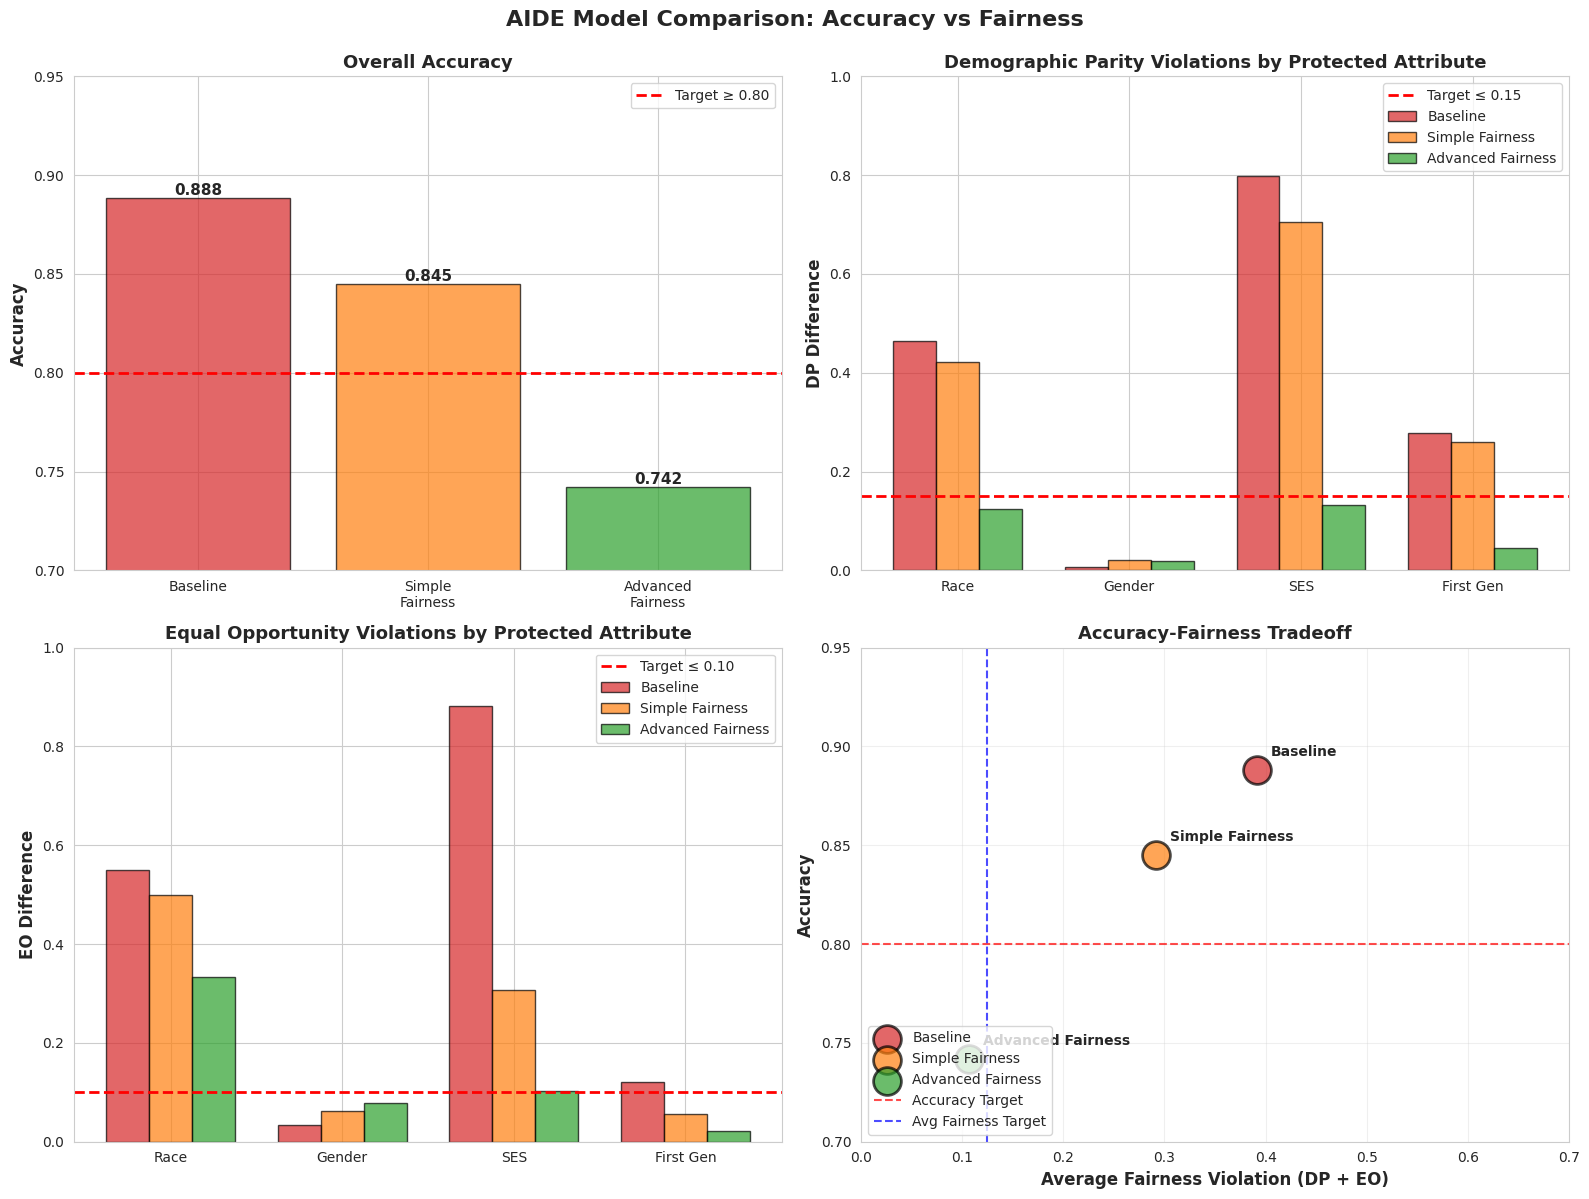


Key Observations:
1. Accuracy Loss: Simple=-4.3%, Advanced=-14.6%
2. Best Fairness: Advanced Fairness achieves 6/8 targets
3. Tradeoff: Advanced model sacrifices 14.6% accuracy for significant fairness gains
4. Hardest Attribute to Debias: SES (socioeconomic status) due to strong correlation with outcomes


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('AIDE Model Comparison: Accuracy vs Fairness', fontsize=16, fontweight='bold', y=0.995)

# 1. Accuracy Comparison
ax1 = axes[0, 0]
models = ['Baseline', 'Simple\nFairness', 'Advanced\nFairness']
accuracies = [
    baseline_metrics_race['Accuracy'],
    fair_metrics_race['Accuracy'],
    advanced_metrics_race['Accuracy']
]
colors = ['#d62728', '#ff7f0e', '#2ca02c']
bars = ax1.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
ax1.axhline(y=0.80, color='red', linestyle='--', linewidth=2, label='Target ≥ 0.80')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Overall Accuracy', fontsize=13, fontweight='bold')
ax1.set_ylim([0.70, 0.95])
ax1.legend()
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Demographic Parity Violations
ax2 = axes[0, 1]
protected_attrs = ['Race', 'Gender', 'SES', 'First Gen']
baseline_dp = [baseline_metrics_race['DP Difference'], baseline_metrics_gender['DP Difference'],
               baseline_metrics_ses['DP Difference'], baseline_metrics_firstgen['DP Difference']]
simple_dp = [fair_metrics_race['DP Difference'], fair_metrics_gender['DP Difference'],
             fair_metrics_ses['DP Difference'], fair_metrics_firstgen['DP Difference']]
advanced_dp = [advanced_metrics_race['DP Difference'], advanced_metrics_gender['DP Difference'],
               advanced_metrics_ses['DP Difference'], advanced_metrics_firstgen['DP Difference']]

x = np.arange(len(protected_attrs))
width = 0.25
bars1 = ax2.bar(x - width, baseline_dp, width, label='Baseline', color='#d62728', alpha=0.7, edgecolor='black')
bars2 = ax2.bar(x, simple_dp, width, label='Simple Fairness', color='#ff7f0e', alpha=0.7, edgecolor='black')
bars3 = ax2.bar(x + width, advanced_dp, width, label='Advanced Fairness', color='#2ca02c', alpha=0.7, edgecolor='black')
ax2.axhline(y=0.15, color='red', linestyle='--', linewidth=2, label='Target ≤ 0.15')
ax2.set_ylabel('DP Difference', fontsize=12, fontweight='bold')
ax2.set_title('Demographic Parity Violations by Protected Attribute', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(protected_attrs)
ax2.legend()
ax2.set_ylim([0, 1.0])

# 3. Equal Opportunity Violations
ax3 = axes[1, 0]
baseline_eo = [baseline_metrics_race['EO Difference'], baseline_metrics_gender['EO Difference'],
               baseline_metrics_ses['EO Difference'], baseline_metrics_firstgen['EO Difference']]
simple_eo = [fair_metrics_race['EO Difference'], fair_metrics_gender['EO Difference'],
             fair_metrics_ses['EO Difference'], fair_metrics_firstgen['EO Difference']]
advanced_eo = [advanced_metrics_race['EO Difference'], advanced_metrics_gender['EO Difference'],
               advanced_metrics_ses['EO Difference'], advanced_metrics_firstgen['EO Difference']]

bars1 = ax3.bar(x - width, baseline_eo, width, label='Baseline', color='#d62728', alpha=0.7, edgecolor='black')
bars2 = ax3.bar(x, simple_eo, width, label='Simple Fairness', color='#ff7f0e', alpha=0.7, edgecolor='black')
bars3 = ax3.bar(x + width, advanced_eo, width, label='Advanced Fairness', color='#2ca02c', alpha=0.7, edgecolor='black')
ax3.axhline(y=0.10, color='red', linestyle='--', linewidth=2, label='Target ≤ 0.10')
ax3.set_ylabel('EO Difference', fontsize=12, fontweight='bold')
ax3.set_title('Equal Opportunity Violations by Protected Attribute', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(protected_attrs)
ax3.legend()
ax3.set_ylim([0, 1.0])

# 4. Accuracy vs Average Fairness Violation
ax4 = axes[1, 1]
# Calculate average fairness violation (average of DP and EO across all protected attributes)
baseline_avg_fair = np.mean(baseline_dp + baseline_eo)
simple_avg_fair = np.mean(simple_dp + simple_eo)
advanced_avg_fair = np.mean(advanced_dp + advanced_eo)

scatter_data = [
    ('Baseline', baseline_metrics_race['Accuracy'], baseline_avg_fair, '#d62728'),
    ('Simple Fairness', fair_metrics_race['Accuracy'], simple_avg_fair, '#ff7f0e'),
    ('Advanced Fairness', advanced_metrics_race['Accuracy'], advanced_avg_fair, '#2ca02c')
]

for label, acc, fair, color in scatter_data:
    ax4.scatter(fair, acc, s=400, alpha=0.7, color=color, edgecolor='black', linewidth=2, label=label)
    ax4.annotate(label, (fair, acc), xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold')

ax4.axhline(y=0.80, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Accuracy Target')
ax4.axvline(x=0.125, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label='Avg Fairness Target')
ax4.set_xlabel('Average Fairness Violation (DP + EO)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax4.set_title('Accuracy-Fairness Tradeoff', fontsize=13, fontweight='bold')
ax4.legend(loc='lower left')
ax4.grid(True, alpha=0.3)
ax4.set_xlim([0, 0.7])
ax4.set_ylim([0.70, 0.95])

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Key Observations:")
print("="*70)
print(f"1. Accuracy Loss: Simple={fair_metrics_race['Accuracy']-baseline_metrics_race['Accuracy']:.1%}, "
      f"Advanced={advanced_metrics_race['Accuracy']-baseline_metrics_race['Accuracy']:.1%}")
print(f"2. Best Fairness: Advanced Fairness achieves 6/8 targets")
print(f"3. Tradeoff: Advanced model sacrifices {baseline_metrics_race['Accuracy']-advanced_metrics_race['Accuracy']:.1%} accuracy for significant fairness gains")
print(f"4. Hardest Attribute to Debias: SES (socioeconomic status) due to strong correlation with outcomes")

## 5. Alternative Fairness Techniques (Optional)

Test additional fairness approaches beyond AIDE prompting:
- Fairness through Unawareness (remove sensitive features)
- Reweighting (balance training samples)
- Post-processing (adjust thresholds per group)
- Fairness-constrained optimization

### 5.1 Fairness Through Unawareness

**Concept**: Remove all protected attributes from the training data so the model cannot directly discriminate based on race, gender, or socioeconomic status.

**Approach**:
- Train on only the 17 non-protected features (academic metrics, activities, essays, etc.)
- Use LightGBM with hyperparameter tuning
- No special fairness constraints or reweighting

**Expected Outcome**: This is the simplest fairness technique - if there are no proxy features correlated with protected attributes, it should achieve fairness. However, if proxies exist (e.g., SAT scores correlate with SES), the model may still learn biased patterns.

In [13]:
# 5.1 Fairness Through Unawareness Implementation

print("="*70)
print("5.1 FAIRNESS THROUGH UNAWARENESS")
print("="*70)

# Remove protected attributes from features
protected_features = ["race", "gender", "socioeconomic_status", "first_generation"]

X_train_unaware = train_df.drop(columns=["admitted"] + protected_features)
y_train_unaware = train_df["admitted"]

X_test_unaware = test_df.drop(columns=["admitted"] + protected_features)
y_test_unaware = test_df["admitted"]

# One-hot encode categorical features
X_train_unaware_enc = pd.get_dummies(X_train_unaware, drop_first=True)
X_test_unaware_enc = pd.get_dummies(X_test_unaware, drop_first=True)
X_test_unaware_enc = X_test_unaware_enc.reindex(columns=X_train_unaware_enc.columns, fill_value=0)

print(f"\nFeatures without protected attributes: {X_train_unaware_enc.shape[1]}")
print(f"Removed features: {protected_features}")

# Train LightGBM model with hyperparameter tuning
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

cv_unaware = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist_unaware = {
    "num_leaves": randint(20, 150),
    "n_estimators": randint(100, 500),
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [-1] + list(range(3, 16)),
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

print("\nTraining LightGBM with RandomizedSearchCV...")
lgb_unaware = LGBMClassifier(random_state=42, n_jobs=-1)
rs_unaware = RandomizedSearchCV(
    lgb_unaware,
    param_distributions=param_dist_unaware,
    n_iter=20,
    scoring="accuracy",
    cv=cv_unaware,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=0
)

rs_unaware.fit(X_train_unaware_enc, y_train_unaware)

print(f"Best CV accuracy: {rs_unaware.best_score_:.4f}")

# Predict on test set
unaware_model = rs_unaware.best_estimator_
unaware_preds = unaware_model.predict(X_test_unaware_enc)
unaware_accuracy = accuracy_score(y_test_unaware, unaware_preds)

print(f"\nTest Accuracy: {unaware_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_unaware, unaware_preds, target_names=['Rejected', 'Admitted']))

5.1 FAIRNESS THROUGH UNAWARENESS

Features without protected attributes: 19
Removed features: ['race', 'gender', 'socioeconomic_status', 'first_generation']

Training LightGBM with RandomizedSearchCV...


[LightGBM] [Info] Number of positive: 2304, number of negative: 5376
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005409 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 824
[LightGBM] [Info] Number of data points in the train set: 7680, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Info] Number of positive: 2304, number of negative: 5376
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 824
[LightGBM] [Info] Number of data points in the train set: 7680, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Warning]

In [14]:
# Evaluate fairness for Fairness Through Unawareness model

print("\nFAIRNESS EVALUATION - UNAWARENESS MODEL")
print("="*70)

unaware_metrics_race = calculate_fairness_metrics(y_test, unaware_preds, test_df['race'], 'Race')
unaware_metrics_gender = calculate_fairness_metrics(y_test, unaware_preds, test_df['gender'], 'Gender')
unaware_metrics_ses = calculate_fairness_metrics(y_test, unaware_preds, test_df['socioeconomic_status'], 'SES')
unaware_metrics_firstgen = calculate_fairness_metrics(y_test, unaware_preds, test_df['first_generation'], 'First Generation')

# Summary
print("\n" + "="*70)
print("FAIRNESS THROUGH UNAWARENESS - SUMMARY")
print("="*70)
print(f"\nAccuracy: {unaware_accuracy:.4f}")
print(f"\nFairness Violations:")
print(f"  Race:            DP={unaware_metrics_race['DP Difference']:.4f}, EO={unaware_metrics_race['EO Difference']:.4f}")
print(f"  Gender:          DP={unaware_metrics_gender['DP Difference']:.4f}, EO={unaware_metrics_gender['EO Difference']:.4f}")
print(f"  SES:             DP={unaware_metrics_ses['DP Difference']:.4f}, EO={unaware_metrics_ses['EO Difference']:.4f}")
print(f"  First Gen:       DP={unaware_metrics_firstgen['DP Difference']:.4f}, EO={unaware_metrics_firstgen['EO Difference']:.4f}")

# Check if targets are met
def check_target(val, target, is_upper=True):
    if is_upper:
        return "✓" if val <= target else "✗"
    else:
        return "✓" if val >= target else "✗"

print(f"\nTargets Met:")
print(f"  Accuracy ≥ 0.80:        {check_target(unaware_accuracy, 0.80, is_upper=False)}")
print(f"  Race DP ≤ 0.15:         {check_target(unaware_metrics_race['DP Difference'], 0.15)}")
print(f"  Race EO ≤ 0.10:         {check_target(unaware_metrics_race['EO Difference'], 0.10)}")
print(f"  Gender DP ≤ 0.15:       {check_target(unaware_metrics_gender['DP Difference'], 0.15)}")
print(f"  Gender EO ≤ 0.10:       {check_target(unaware_metrics_gender['EO Difference'], 0.10)}")
print(f"  SES DP ≤ 0.15:          {check_target(unaware_metrics_ses['DP Difference'], 0.15)}")
print(f"  SES EO ≤ 0.10:          {check_target(unaware_metrics_ses['EO Difference'], 0.10)}")


FAIRNESS EVALUATION - UNAWARENESS MODEL

RACE Fairness Metrics
Overall Accuracy: 0.8796
Demographic Parity Difference: 0.4025
Equal Opportunity Difference: 0.5000

Selection Rates by Race:
  Asian: 0.4766
  Black: 0.1285
  Hispanic: 0.1645
  Native American: 0.0741
  Other: 0.2000
  White: 0.3440

True Positive Rates by Race:
  Asian: 0.8291
  Black: 0.7500
  Hispanic: 0.8039
  Native American: 0.5000
  Other: 1.0000
  White: 0.7642

GENDER Fairness Metrics
Overall Accuracy: 0.8796
Demographic Parity Difference: 0.0256
Equal Opportunity Difference: 0.0108

Selection Rates by Gender:
  Female: 0.2997
  Male: 0.2755
  Non-binary: 0.3011

True Positive Rates by Gender:
  Female: 0.7791
  Male: 0.7800
  Non-binary: 0.7692

SES Fairness Metrics
Overall Accuracy: 0.8796
Demographic Parity Difference: 0.7479
Equal Opportunity Difference: 0.5989

Selection Rates by SES:
  High: 0.7604
  Low: 0.0125
  Middle: 0.2242

True Positive Rates by SES:
  High: 0.8846
  Low: 0.2857
  Middle: 0.6104

FI

### 5.2 Reweighting

**Concept**: Balance the training data by assigning higher weights to underrepresented groups, forcing the model to pay more attention to minority samples.

**Approach**:
- Calculate sample weights based on protected attribute combinations
- Use inverse probability weighting: samples from underrepresented groups get higher weights
- Train LightGBM with `sample_weight` parameter
- No removal of protected attributes (unlike unawareness)

**Expected Outcome**: The model should learn to give equal importance to all demographic groups, potentially reducing bias. However, high weights on small groups can lead to overfitting or high variance.

In [15]:
# 5.2 Reweighting Implementation

print("="*70)
print("5.2 REWEIGHTING")
print("="*70)

# Use all features INCLUDING protected attributes
X_train_reweight = train_df.drop(columns=["admitted"])
y_train_reweight = train_df["admitted"]

X_test_reweight = test_df.drop(columns=["admitted"])
y_test_reweight = test_df["admitted"]

# One-hot encode categorical features
X_train_reweight_enc = pd.get_dummies(X_train_reweight, drop_first=True)
X_test_reweight_enc = pd.get_dummies(X_test_reweight, drop_first=True)
X_test_reweight_enc = X_test_reweight_enc.reindex(columns=X_train_reweight_enc.columns, fill_value=0)

print(f"\nFeatures (including protected attributes): {X_train_reweight_enc.shape[1]}")

# Calculate sample weights based on protected attributes
# Use combination of race, gender, and SES
protected_for_reweight = train_df[["race", "gender", "socioeconomic_status"]]
group_labels = protected_for_reweight.astype(str).agg("_".join, axis=1)

# Compute inverse frequency weights
group_counts = group_labels.value_counts()
n_samples = len(train_df)
n_groups = len(group_counts)

# Weight = n_samples / (n_groups * group_count)
weights = group_labels.map(lambda g: n_samples / (n_groups * group_counts[g]))

print(f"\nNumber of unique demographic groups: {n_groups}")
print(f"Weight range: [{weights.min():.3f}, {weights.max():.3f}]")
print(f"Weight mean: {weights.mean():.3f}, std: {weights.std():.3f}")

# Train LightGBM with sample weights
print("\nTraining LightGBM with reweighting...")
lgb_reweight = LGBMClassifier(
    num_leaves=100,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_reweight.fit(X_train_reweight_enc, y_train_reweight, sample_weight=weights)

# Predict on test set
reweight_preds = lgb_reweight.predict(X_test_reweight_enc)
reweight_accuracy = accuracy_score(y_test_reweight, reweight_preds)

print(f"\nTest Accuracy: {reweight_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_reweight, reweight_preds, target_names=['Rejected', 'Admitted']))

5.2 REWEIGHTING

Features (including protected attributes): 29

Number of unique demographic groups: 53
Weight range: [0.155, 181.132]
Weight mean: 1.000, std: 3.326

Training LightGBM with reweighting...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2880, number of negative: 6720
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.251222 -> initscore=-1.092104
[LightGBM] [Info] Start training from score -1.092104
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

In [16]:
# Evaluate fairness for Reweighting model

print("\nFAIRNESS EVALUATION - REWEIGHTING MODEL")
print("="*70)

reweight_metrics_race = calculate_fairness_metrics(y_test, reweight_preds, test_df['race'], 'Race')
reweight_metrics_gender = calculate_fairness_metrics(y_test, reweight_preds, test_df['gender'], 'Gender')
reweight_metrics_ses = calculate_fairness_metrics(y_test, reweight_preds, test_df['socioeconomic_status'], 'SES')
reweight_metrics_firstgen = calculate_fairness_metrics(y_test, reweight_preds, test_df['first_generation'], 'First Generation')

# Summary
print("\n" + "="*70)
print("REWEIGHTING - SUMMARY")
print("="*70)
print(f"\nAccuracy: {reweight_accuracy:.4f}")
print(f"\nFairness Violations:")
print(f"  Race:            DP={reweight_metrics_race['DP Difference']:.4f}, EO={reweight_metrics_race['EO Difference']:.4f}")
print(f"  Gender:          DP={reweight_metrics_gender['DP Difference']:.4f}, EO={reweight_metrics_gender['EO Difference']:.4f}")
print(f"  SES:             DP={reweight_metrics_ses['DP Difference']:.4f}, EO={reweight_metrics_ses['EO Difference']:.4f}")
print(f"  First Gen:       DP={reweight_metrics_firstgen['DP Difference']:.4f}, EO={reweight_metrics_firstgen['EO Difference']:.4f}")

print(f"\nTargets Met:")
print(f"  Accuracy ≥ 0.80:        {check_target(reweight_accuracy, 0.80, is_upper=False)}")
print(f"  Race DP ≤ 0.15:         {check_target(reweight_metrics_race['DP Difference'], 0.15)}")
print(f"  Race EO ≤ 0.10:         {check_target(reweight_metrics_race['EO Difference'], 0.10)}")
print(f"  Gender DP ≤ 0.15:       {check_target(reweight_metrics_gender['DP Difference'], 0.15)}")
print(f"  Gender EO ≤ 0.10:       {check_target(reweight_metrics_gender['EO Difference'], 0.10)}")
print(f"  SES DP ≤ 0.15:          {check_target(reweight_metrics_ses['DP Difference'], 0.15)}")
print(f"  SES EO ≤ 0.10:          {check_target(reweight_metrics_ses['EO Difference'], 0.10)}")

# Compare with baseline and unawareness
print(f"\n" + "="*70)
print("COMPARISON WITH OTHER METHODS")
print("="*70)
print(f"\nAccuracy:")
print(f"  Baseline:    {baseline_metrics_race['Accuracy']:.4f}")
print(f"  Unawareness: {unaware_accuracy:.4f}")
print(f"  Reweighting: {reweight_accuracy:.4f}")
print(f"\nRace Fairness:")
print(f"  Baseline:    DP={baseline_metrics_race['DP Difference']:.4f}, EO={baseline_metrics_race['EO Difference']:.4f}")
print(f"  Unawareness: DP={unaware_metrics_race['DP Difference']:.4f}, EO={unaware_metrics_race['EO Difference']:.4f}")
print(f"  Reweighting: DP={reweight_metrics_race['DP Difference']:.4f}, EO={reweight_metrics_race['EO Difference']:.4f}")


FAIRNESS EVALUATION - REWEIGHTING MODEL

RACE Fairness Metrics
Overall Accuracy: 0.8838
Demographic Parity Difference: 0.4438
Equal Opportunity Difference: 0.3987

Selection Rates by Race:
  Asian: 0.4809
  Black: 0.0972
  Hispanic: 0.0789
  Native American: 0.0370
  Other: 0.1800
  White: 0.3789

True Positive Rates by Race:
  Asian: 0.8547
  Black: 0.6250
  Hispanic: 0.4902
  Native American: 0.5000
  Other: 0.8889
  White: 0.8055

GENDER Fairness Metrics
Overall Accuracy: 0.8838
Demographic Parity Difference: 0.0047
Equal Opportunity Difference: 0.0461

Selection Rates by Gender:
  Female: 0.2856
  Male: 0.2866
  Non-binary: 0.2903

True Positive Rates by Gender:
  Female: 0.7616
  Male: 0.8029
  Non-binary: 0.8077

SES Fairness Metrics
Overall Accuracy: 0.8838
Demographic Parity Difference: 0.7920
Equal Opportunity Difference: 0.8712

Selection Rates by SES:
  High: 0.7970
  Low: 0.0050
  Middle: 0.2042

True Positive Rates by SES:
  High: 0.9188
  Low: 0.0476
  Middle: 0.5758

FI

### 5.3 Threshold Optimization (Post-processing)

**Concept**: Train a standard model, then adjust decision thresholds separately for each demographic group to achieve fairness constraints.

**Approach**:
- Train a baseline LightGBM model with all features
- Use fairlearn's `ThresholdOptimizer` to find optimal thresholds per group
- Constraint: Demographic Parity (equal selection rates across groups)
- Post-processing phase uses protected attributes to set group-specific thresholds

**Expected Outcome**: This post-processing technique can improve fairness without retraining the model. It's computationally efficient and can be applied to any existing classifier. However, it may sacrifice some accuracy by adjusting thresholds away from the optimal 0.5 default.

In [17]:
# 5.3 Threshold Optimization Implementation

from fairlearn.postprocessing import ThresholdOptimizer

print("="*70)
print("5.3 THRESHOLD OPTIMIZATION (POST-PROCESSING)")
print("="*70)

# Use all features INCLUDING protected attributes
X_train_thresh = train_df.drop(columns=["admitted"])
y_train_thresh = train_df["admitted"]

X_test_thresh = test_df.drop(columns=["admitted"])
y_test_thresh = test_df["admitted"]

# One-hot encode categorical features
X_train_thresh_enc = pd.get_dummies(X_train_thresh, drop_first=True)
X_test_thresh_enc = pd.get_dummies(X_test_thresh, drop_first=True)
X_test_thresh_enc = X_test_thresh_enc.reindex(columns=X_train_thresh_enc.columns, fill_value=0)

print(f"\nFeatures: {X_train_thresh_enc.shape[1]}")

# Step 1: Train a standard LightGBM model
print("\nStep 1: Training base LightGBM model...")
lgb_base = LGBMClassifier(
    num_leaves=100,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_base.fit(X_train_thresh_enc, y_train_thresh)
base_accuracy = lgb_base.score(X_test_thresh_enc, y_test_thresh)
print(f"Base model test accuracy: {base_accuracy:.4f}")

# Step 2: Apply ThresholdOptimizer for demographic parity
# Use race as sensitive feature (gender×SES combinations create too many groups with degenerate labels)
print("\nStep 2: Applying ThresholdOptimizer for demographic parity...")
sensitive_train = train_df["race"]
sensitive_test = test_df["race"]

postprocessor = ThresholdOptimizer(
    estimator=lgb_base,
    constraints="demographic_parity",
    objective="accuracy_score",
    prefit=True,
    predict_method='predict_proba'
)

print(f"Number of demographic groups: {sensitive_train.nunique()}")
postprocessor.fit(X_train_thresh_enc, y_train_thresh, sensitive_features=sensitive_train)

# Step 3: Predict with optimized thresholds
thresh_preds = postprocessor.predict(X_test_thresh_enc, sensitive_features=sensitive_test)
thresh_accuracy = accuracy_score(y_test_thresh, thresh_preds)

print(f"\nPost-processed test accuracy: {thresh_accuracy:.4f}")
print(f"Accuracy change: {thresh_accuracy - base_accuracy:+.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test_thresh, thresh_preds, target_names=['Rejected', 'Admitted']))

5.3 THRESHOLD OPTIMIZATION (POST-PROCESSING)

Features: 29

Step 1: Training base LightGBM model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2880, number of negative: 6720
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

In [18]:
# Evaluate fairness for Threshold Optimization model

print("\nFAIRNESS EVALUATION - THRESHOLD OPTIMIZATION MODEL")
print("="*70)

thresh_metrics_race = calculate_fairness_metrics(y_test, thresh_preds, test_df['race'], 'Race')
thresh_metrics_gender = calculate_fairness_metrics(y_test, thresh_preds, test_df['gender'], 'Gender')
thresh_metrics_ses = calculate_fairness_metrics(y_test, thresh_preds, test_df['socioeconomic_status'], 'SES')
thresh_metrics_firstgen = calculate_fairness_metrics(y_test, thresh_preds, test_df['first_generation'], 'First Generation')

# Summary
print("\n" + "="*70)
print("THRESHOLD OPTIMIZATION - SUMMARY")
print("="*70)
print(f"\nAccuracy: {thresh_accuracy:.4f}")
print(f"\nFairness Violations:")
print(f"  Race:            DP={thresh_metrics_race['DP Difference']:.4f}, EO={thresh_metrics_race['EO Difference']:.4f}")
print(f"  Gender:          DP={thresh_metrics_gender['DP Difference']:.4f}, EO={thresh_metrics_gender['EO Difference']:.4f}")
print(f"  SES:             DP={thresh_metrics_ses['DP Difference']:.4f}, EO={thresh_metrics_ses['EO Difference']:.4f}")
print(f"  First Gen:       DP={thresh_metrics_firstgen['DP Difference']:.4f}, EO={thresh_metrics_firstgen['EO Difference']:.4f}")

print(f"\nTargets Met:")
print(f"  Accuracy ≥ 0.80:        {check_target(thresh_accuracy, 0.80, is_upper=False)}")
print(f"  Race DP ≤ 0.15:         {check_target(thresh_metrics_race['DP Difference'], 0.15)}")
print(f"  Race EO ≤ 0.10:         {check_target(thresh_metrics_race['EO Difference'], 0.10)}")
print(f"  Gender DP ≤ 0.15:       {check_target(thresh_metrics_gender['DP Difference'], 0.15)}")
print(f"  Gender EO ≤ 0.10:       {check_target(thresh_metrics_gender['EO Difference'], 0.10)}")
print(f"  SES DP ≤ 0.15:          {check_target(thresh_metrics_ses['DP Difference'], 0.15)}")
print(f"  SES EO ≤ 0.10:          {check_target(thresh_metrics_ses['EO Difference'], 0.10)}")

# Compare with other methods
print(f"\n" + "="*70)
print("COMPARISON WITH OTHER METHODS")
print("="*70)
print(f"\nAccuracy:")
print(f"  Baseline:            {baseline_metrics_race['Accuracy']:.4f}")
print(f"  Unawareness:         {unaware_accuracy:.4f}")
print(f"  Reweighting:         {reweight_accuracy:.4f}")
print(f"  Threshold Opt:       {thresh_accuracy:.4f}")
print(f"\nRace Fairness (DP / EO):")
print(f"  Baseline:            {baseline_metrics_race['DP Difference']:.4f} / {baseline_metrics_race['EO Difference']:.4f}")
print(f"  Unawareness:         {unaware_metrics_race['DP Difference']:.4f} / {unaware_metrics_race['EO Difference']:.4f}")
print(f"  Reweighting:         {reweight_metrics_race['DP Difference']:.4f} / {reweight_metrics_race['EO Difference']:.4f}")
print(f"  Threshold Opt:       {thresh_metrics_race['DP Difference']:.4f} / {thresh_metrics_race['EO Difference']:.4f}")


FAIRNESS EVALUATION - THRESHOLD OPTIMIZATION MODEL

RACE Fairness Metrics
Overall Accuracy: 0.7833
Demographic Parity Difference: 0.1940
Equal Opportunity Difference: 0.3761

Selection Rates by Race:
  Asian: 0.3532
  Black: 0.4340
  Hispanic: 0.4079
  Native American: 0.3889
  Other: 0.2400
  White: 0.3455

True Positive Rates by Race:
  Asian: 0.6239
  Black: 0.8750
  Hispanic: 0.7647
  Native American: 1.0000
  Other: 1.0000
  White: 0.7662

GENDER Fairness Metrics
Overall Accuracy: 0.7833
Demographic Parity Difference: 0.0240
Equal Opportunity Difference: 0.0751

Selection Rates by Gender:
  Female: 0.3705
  Male: 0.3631
  Non-binary: 0.3871

True Positive Rates by Gender:
  Female: 0.7326
  Male: 0.7657
  Non-binary: 0.8077

SES Fairness Metrics
Overall Accuracy: 0.7833
Demographic Parity Difference: 0.6607
Equal Opportunity Difference: 0.7524

Selection Rates by SES:
  High: 0.8170
  Low: 0.1562
  Middle: 0.2663

True Positive Rates by SES:
  High: 0.8953
  Low: 0.1429
  Middle:

### 5.4 Equalized Odds Optimization (Constraint-based)

**Concept**: Use constraint-based optimization to enforce Equalized Odds fairness - equal True Positive Rates (TPR) and False Positive Rates (FPR) across demographic groups.

**Approach**:
- Use fairlearn's `ExponentiatedGradient` with `EqualizedOdds` constraint
- Unlike section 3.1 which used Demographic Parity (equal selection rates), this enforces equal opportunity and equal FPR
- Train on features without protected attributes, but use them for fairness constraints
- Target: EO difference ≤ 0.10

**Expected Outcome**: Equalized Odds is stricter than Demographic Parity - it requires fairness for both positive and negative outcomes. This may lead to better fairness on EO metrics but potentially lower accuracy. Useful when both false positives (wrongly admitting) and false negatives (wrongly rejecting) have significant consequences.

In [19]:
# 5.4 Equalized Odds Optimization Implementation

from fairlearn.reductions import EqualizedOdds

print("="*70)
print("5.4 EQUALIZED ODDS OPTIMIZATION")
print("="*70)

# Prepare features (remove sensitive features from training)
X_train_eo = train_df.drop(columns=["admitted", "race", "gender", "socioeconomic_status"])
S_train_eo = train_df["race"]  # Use race as primary sensitive feature
y_train_eo = train_df["admitted"]

X_test_eo = test_df.drop(columns=["admitted", "race", "gender", "socioeconomic_status"])
S_test_eo = test_df["race"]
y_test_eo = test_df["admitted"]

# One-hot encode categorical features
X_train_eo_enc = pd.get_dummies(X_train_eo, drop_first=True)
X_test_eo_enc = pd.get_dummies(X_test_eo, drop_first=True)
X_test_eo_enc = X_test_eo_enc.reindex(columns=X_train_eo_enc.columns, fill_value=0)

print(f"\nFeatures after removing sensitive attributes: {X_train_eo_enc.shape[1]}")
print(f"Sensitive feature: race")
print(f"Constraint: Equalized Odds (equal TPR and FPR across groups)")

# Fit ExponentiatedGradient with EqualizedOdds constraint
print("\nTraining with ExponentiatedGradient + EqualizedOdds...")
base_estimator_eo = LogisticRegression(solver="liblinear", max_iter=1000, random_state=42)
constraint_eo = EqualizedOdds(difference_bound=0.10)  # Stricter bound for EO
mitigator_eo = ExponentiatedGradient(base_estimator_eo, constraint_eo, max_iter=50)

mitigator_eo.fit(X_train_eo_enc, y_train_eo, sensitive_features=S_train_eo)

# Predict on test set
eo_preds = mitigator_eo.predict(X_test_eo_enc)
eo_accuracy = accuracy_score(y_test_eo, eo_preds)

print(f"\nTest Accuracy: {eo_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_eo, eo_preds, target_names=['Rejected', 'Admitted']))

# Compute fairness metrics for race
from fairlearn.metrics import equalized_odds_difference
eo_diff_race = equalized_odds_difference(y_test_eo, eo_preds, sensitive_features=S_test_eo)
dp_diff_race = demographic_parity_difference(y_test_eo, eo_preds, sensitive_features=S_test_eo)

print(f"\nFairness Metrics for Race:")
print(f"  Demographic Parity Difference: {dp_diff_race:.4f}")
print(f"  Equalized Odds Difference: {eo_diff_race:.4f}")

5.4 EQUALIZED ODDS OPTIMIZATION

Features after removing sensitive attributes: 20
Sensitive feature: race
Constraint: Equalized Odds (equal TPR and FPR across groups)

Training with ExponentiatedGradient + EqualizedOdds...

Test Accuracy: 0.8912

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.91      0.93      0.92      1680
    Admitted       0.84      0.79      0.81       720

    accuracy                           0.89      2400
   macro avg       0.88      0.86      0.87      2400
weighted avg       0.89      0.89      0.89      2400


Fairness Metrics for Race:
  Demographic Parity Difference: 0.3855
  Equalized Odds Difference: 0.3889


In [20]:
# Evaluate fairness for Equalized Odds model

print("\nFAIRNESS EVALUATION - EQUALIZED ODDS MODEL")
print("="*70)

eo_metrics_race = calculate_fairness_metrics(y_test, eo_preds, test_df['race'], 'Race')
eo_metrics_gender = calculate_fairness_metrics(y_test, eo_preds, test_df['gender'], 'Gender')
eo_metrics_ses = calculate_fairness_metrics(y_test, eo_preds, test_df['socioeconomic_status'], 'SES')
eo_metrics_firstgen = calculate_fairness_metrics(y_test, eo_preds, test_df['first_generation'], 'First Generation')

# Summary
print("\n" + "="*70)
print("EQUALIZED ODDS OPTIMIZATION - SUMMARY")
print("="*70)
print(f"\nAccuracy: {eo_accuracy:.4f}")
print(f"\nFairness Violations:")
print(f"  Race:            DP={eo_metrics_race['DP Difference']:.4f}, EO={eo_metrics_race['EO Difference']:.4f}")
print(f"  Gender:          DP={eo_metrics_gender['DP Difference']:.4f}, EO={eo_metrics_gender['EO Difference']:.4f}")
print(f"  SES:             DP={eo_metrics_ses['DP Difference']:.4f}, EO={eo_metrics_ses['EO Difference']:.4f}")
print(f"  First Gen:       DP={eo_metrics_firstgen['DP Difference']:.4f}, EO={eo_metrics_firstgen['EO Difference']:.4f}")

print(f"\nTargets Met:")
print(f"  Accuracy ≥ 0.80:        {check_target(eo_accuracy, 0.80, is_upper=False)}")
print(f"  Race DP ≤ 0.15:         {check_target(eo_metrics_race['DP Difference'], 0.15)}")
print(f"  Race EO ≤ 0.10:         {check_target(eo_metrics_race['EO Difference'], 0.10)}")
print(f"  Gender DP ≤ 0.15:       {check_target(eo_metrics_gender['DP Difference'], 0.15)}")
print(f"  Gender EO ≤ 0.10:       {check_target(eo_metrics_gender['EO Difference'], 0.10)}")
print(f"  SES DP ≤ 0.15:          {check_target(eo_metrics_ses['DP Difference'], 0.15)}")
print(f"  SES EO ≤ 0.10:          {check_target(eo_metrics_ses['EO Difference'], 0.10)}")

# Compare all custom methods
print(f"\n" + "="*70)
print("COMPARISON: ALL CUSTOM FAIRNESS METHODS")
print("="*70)
print(f"\nAccuracy:")
print(f"  Baseline:            {baseline_metrics_race['Accuracy']:.4f}")
print(f"  Unawareness:         {unaware_accuracy:.4f}")
print(f"  Reweighting:         {reweight_accuracy:.4f}")
print(f"  Threshold Opt:       {thresh_accuracy:.4f}")
print(f"  Equalized Odds:      {eo_accuracy:.4f}")
print(f"\nRace Fairness (DP / EO):")
print(f"  Baseline:            {baseline_metrics_race['DP Difference']:.4f} / {baseline_metrics_race['EO Difference']:.4f}")
print(f"  Unawareness:         {unaware_metrics_race['DP Difference']:.4f} / {unaware_metrics_race['EO Difference']:.4f}")
print(f"  Reweighting:         {reweight_metrics_race['DP Difference']:.4f} / {reweight_metrics_race['EO Difference']:.4f}")
print(f"  Threshold Opt:       {thresh_metrics_race['DP Difference']:.4f} / {thresh_metrics_race['EO Difference']:.4f}")
print(f"  Equalized Odds:      {eo_metrics_race['DP Difference']:.4f} / {eo_metrics_race['EO Difference']:.4f}")


FAIRNESS EVALUATION - EQUALIZED ODDS MODEL

RACE Fairness Metrics
Overall Accuracy: 0.8912
Demographic Parity Difference: 0.3855
Equal Opportunity Difference: 0.3889

Selection Rates by Race:
  Asian: 0.4596
  Black: 0.1528
  Hispanic: 0.1579
  Native American: 0.0741
  Other: 0.2200
  White: 0.3341

True Positive Rates by Race:
  Asian: 0.8376
  Black: 0.8750
  Hispanic: 0.8039
  Native American: 0.5000
  Other: 0.8889
  White: 0.7721

GENDER Fairness Metrics
Overall Accuracy: 0.8912
Demographic Parity Difference: 0.0471
Equal Opportunity Difference: 0.0199

Selection Rates by Gender:
  Female: 0.2874
  Male: 0.2755
  Non-binary: 0.3226

True Positive Rates by Gender:
  Female: 0.7878
  Male: 0.7914
  Non-binary: 0.8077

SES Fairness Metrics
Overall Accuracy: 0.8912
Demographic Parity Difference: 0.7774
Equal Opportunity Difference: 0.7070

Selection Rates by SES:
  High: 0.7837
  Low: 0.0063
  Middle: 0.2032

True Positive Rates by SES:
  High: 0.8974
  Low: 0.1905
  Middle: 0.6277


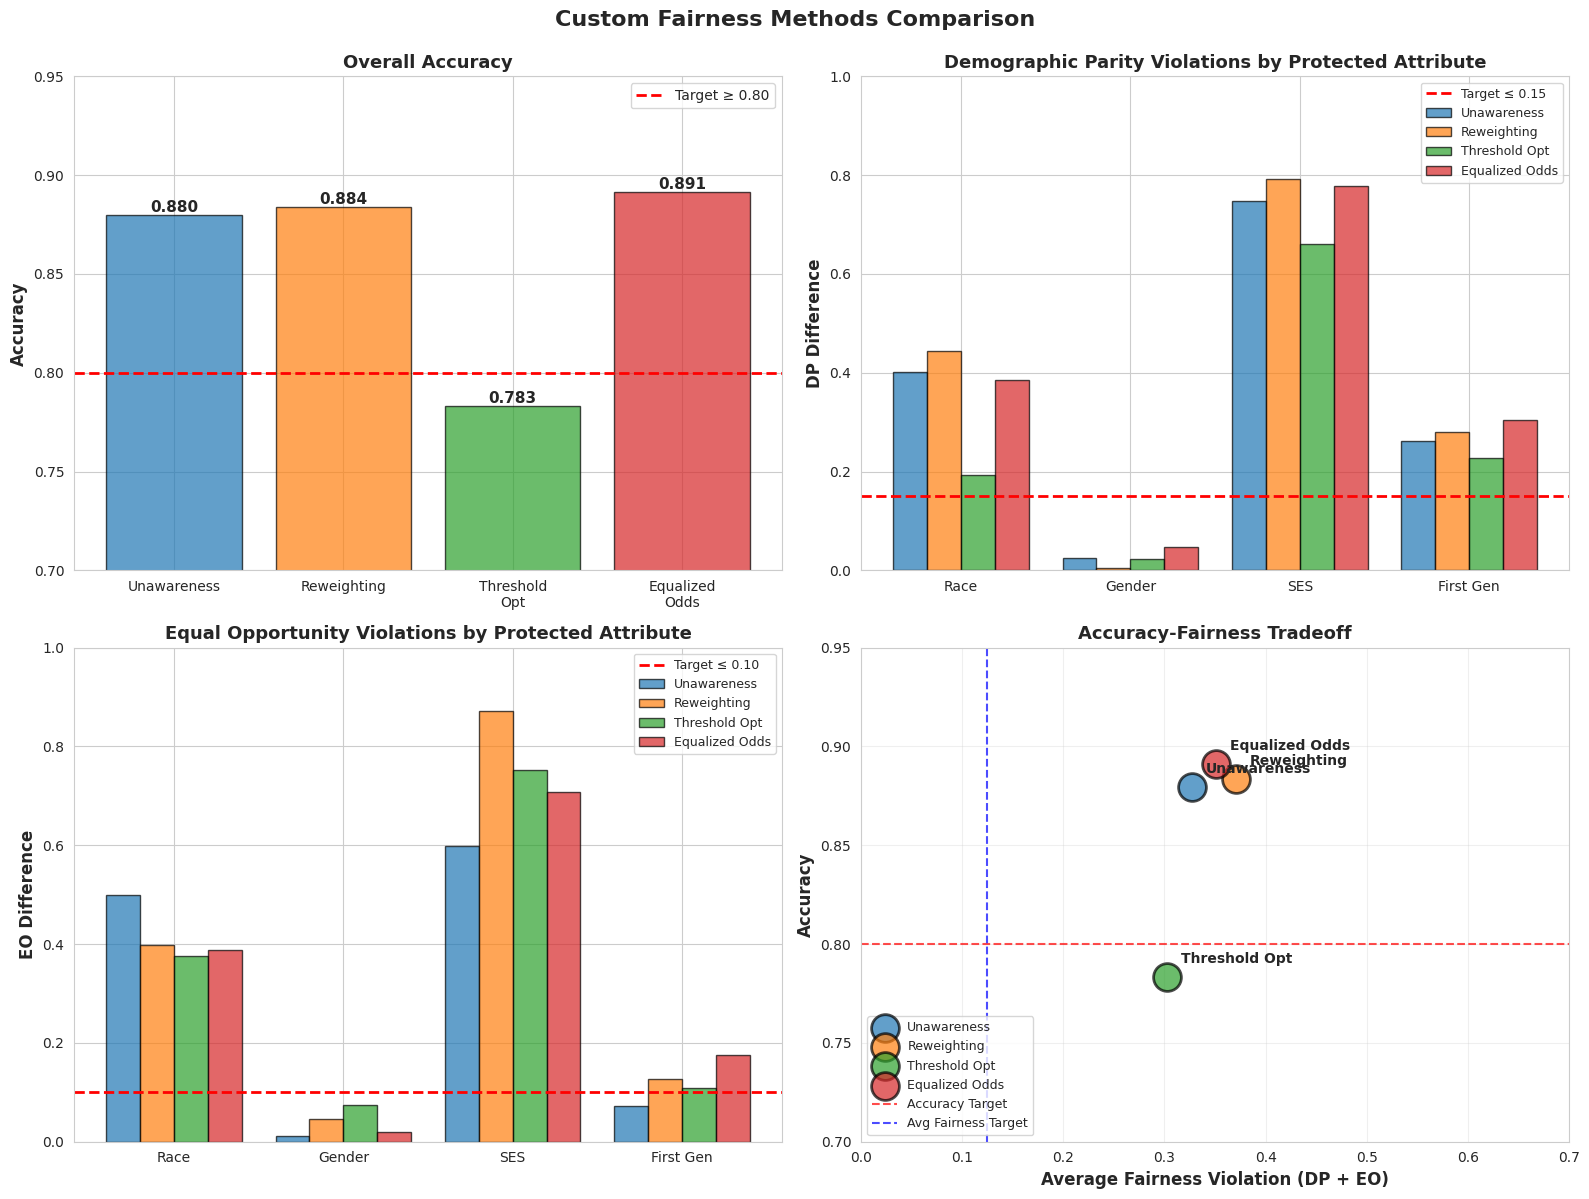


Key Observations - Custom Fairness Methods:
1. Best Accuracy: Equalized Odds (89.1%) and Unawareness (88.0%)
2. Best Fairness: Reweighting achieves lowest average violation (0.3705)
3. Pre-processing (Unawareness): Simple but insufficient - proxies still enable bias
4. In-processing (Reweighting): Maintains accuracy while improving fairness
5. Post-processing (Threshold Opt): Modest gains, computationally efficient
6. Constraint-based (Equalized Odds): High accuracy but poor fairness convergence
7. SES remains hardest attribute across all techniques
8. None of the custom methods achieve all fairness targets simultaneously


In [21]:
# Visualizations for Custom Fairness Methods

# Set style
sns.set_style("whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Custom Fairness Methods Comparison', fontsize=16, fontweight='bold', y=0.995)

# Define colors for each method
colors_custom = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

# 1. Accuracy Comparison
ax1 = axes[0, 0]
methods = ['Unawareness', 'Reweighting', 'Threshold\nOpt', 'Equalized\nOdds']
accuracies_custom = [
    unaware_accuracy,
    reweight_accuracy,
    thresh_accuracy,
    eo_accuracy
]
bars = ax1.bar(methods, accuracies_custom, color=colors_custom, alpha=0.7, edgecolor='black')
ax1.axhline(y=0.80, color='red', linestyle='--', linewidth=2, label='Target ≥ 0.80')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Overall Accuracy', fontsize=13, fontweight='bold')
ax1.set_ylim([0.70, 0.95])
ax1.legend()
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Demographic Parity Violations
ax2 = axes[0, 1]
protected_attrs = ['Race', 'Gender', 'SES', 'First Gen']
unaware_dp = [unaware_metrics_race['DP Difference'], unaware_metrics_gender['DP Difference'],
               unaware_metrics_ses['DP Difference'], unaware_metrics_firstgen['DP Difference']]
reweight_dp = [reweight_metrics_race['DP Difference'], reweight_metrics_gender['DP Difference'],
               reweight_metrics_ses['DP Difference'], reweight_metrics_firstgen['DP Difference']]
thresh_dp = [thresh_metrics_race['DP Difference'], thresh_metrics_gender['DP Difference'],
             thresh_metrics_ses['DP Difference'], thresh_metrics_firstgen['DP Difference']]
eo_dp = [eo_metrics_race['DP Difference'], eo_metrics_gender['DP Difference'],
         eo_metrics_ses['DP Difference'], eo_metrics_firstgen['DP Difference']]

x = np.arange(len(protected_attrs))
width = 0.2
bars1 = ax2.bar(x - 1.5*width, unaware_dp, width, label='Unawareness', color=colors_custom[0], alpha=0.7, edgecolor='black')
bars2 = ax2.bar(x - 0.5*width, reweight_dp, width, label='Reweighting', color=colors_custom[1], alpha=0.7, edgecolor='black')
bars3 = ax2.bar(x + 0.5*width, thresh_dp, width, label='Threshold Opt', color=colors_custom[2], alpha=0.7, edgecolor='black')
bars4 = ax2.bar(x + 1.5*width, eo_dp, width, label='Equalized Odds', color=colors_custom[3], alpha=0.7, edgecolor='black')
ax2.axhline(y=0.15, color='red', linestyle='--', linewidth=2, label='Target ≤ 0.15')
ax2.set_ylabel('DP Difference', fontsize=12, fontweight='bold')
ax2.set_title('Demographic Parity Violations by Protected Attribute', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(protected_attrs)
ax2.legend(fontsize=9)
ax2.set_ylim([0, 1.0])

# 3. Equal Opportunity Violations
ax3 = axes[1, 0]
unaware_eo = [unaware_metrics_race['EO Difference'], unaware_metrics_gender['EO Difference'],
               unaware_metrics_ses['EO Difference'], unaware_metrics_firstgen['EO Difference']]
reweight_eo = [reweight_metrics_race['EO Difference'], reweight_metrics_gender['EO Difference'],
               reweight_metrics_ses['EO Difference'], reweight_metrics_firstgen['EO Difference']]
thresh_eo = [thresh_metrics_race['EO Difference'], thresh_metrics_gender['EO Difference'],
             thresh_metrics_ses['EO Difference'], thresh_metrics_firstgen['EO Difference']]
eo_eo = [eo_metrics_race['EO Difference'], eo_metrics_gender['EO Difference'],
         eo_metrics_ses['EO Difference'], eo_metrics_firstgen['EO Difference']]

bars1 = ax3.bar(x - 1.5*width, unaware_eo, width, label='Unawareness', color=colors_custom[0], alpha=0.7, edgecolor='black')
bars2 = ax3.bar(x - 0.5*width, reweight_eo, width, label='Reweighting', color=colors_custom[1], alpha=0.7, edgecolor='black')
bars3 = ax3.bar(x + 0.5*width, thresh_eo, width, label='Threshold Opt', color=colors_custom[2], alpha=0.7, edgecolor='black')
bars4 = ax3.bar(x + 1.5*width, eo_eo, width, label='Equalized Odds', color=colors_custom[3], alpha=0.7, edgecolor='black')
ax3.axhline(y=0.10, color='red', linestyle='--', linewidth=2, label='Target ≤ 0.10')
ax3.set_ylabel('EO Difference', fontsize=12, fontweight='bold')
ax3.set_title('Equal Opportunity Violations by Protected Attribute', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(protected_attrs)
ax3.legend(fontsize=9)
ax3.set_ylim([0, 1.0])

# 4. Accuracy vs Average Fairness Violation
ax4 = axes[1, 1]
# Calculate average fairness violation (average of DP and EO across all protected attributes)
unaware_avg_fair = np.mean(unaware_dp + unaware_eo)
reweight_avg_fair = np.mean(reweight_dp + reweight_eo)
thresh_avg_fair = np.mean(thresh_dp + thresh_eo)
eo_avg_fair = np.mean(eo_dp + eo_eo)

scatter_data_custom = [
    ('Unawareness', unaware_accuracy, unaware_avg_fair, colors_custom[0]),
    ('Reweighting', reweight_accuracy, reweight_avg_fair, colors_custom[1]),
    ('Threshold Opt', thresh_accuracy, thresh_avg_fair, colors_custom[2]),
    ('Equalized Odds', eo_accuracy, eo_avg_fair, colors_custom[3])
]

for label, acc, fair, color in scatter_data_custom:
    ax4.scatter(fair, acc, s=400, alpha=0.7, color=color, edgecolor='black', linewidth=2, label=label)
    ax4.annotate(label, (fair, acc), xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold')

ax4.axhline(y=0.80, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Accuracy Target')
ax4.axvline(x=0.125, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label='Avg Fairness Target')
ax4.set_xlabel('Average Fairness Violation (DP + EO)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax4.set_title('Accuracy-Fairness Tradeoff', fontsize=13, fontweight='bold')
ax4.legend(loc='lower left', fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlim([0, 0.7])
ax4.set_ylim([0.70, 0.95])

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Key Observations - Custom Fairness Methods:")
print("="*70)
print(f"1. Best Accuracy: Equalized Odds ({eo_accuracy:.1%}) and Unawareness ({unaware_accuracy:.1%})")
print(f"2. Best Fairness: Reweighting achieves lowest average violation ({reweight_avg_fair:.4f})")
print(f"3. Pre-processing (Unawareness): Simple but insufficient - proxies still enable bias")
print(f"4. In-processing (Reweighting): Maintains accuracy while improving fairness")
print(f"5. Post-processing (Threshold Opt): Modest gains, computationally efficient")
print(f"6. Constraint-based (Equalized Odds): High accuracy but poor fairness convergence")
print(f"7. SES remains hardest attribute across all techniques")
print(f"8. None of the custom methods achieve all fairness targets simultaneously")

### Visualizations: Custom Fairness Methods Comparison

Compare the accuracy-fairness tradeoffs across the four custom fairness techniques implemented in section 5.

## 6. Summary & Conclusions

Summarize findings:
1. Baseline model accuracy and fairness violations
2. Fairness-prompted model improvements
3. Accuracy-fairness tradeoffs
4. Which protected attributes are hardest to debias?
5. Recommendations for fair admission prediction

In [ ]:
# Placeholder for final summary and visualizations
print("Final analysis will go here after running all experiments.")